In [24]:
import sys
sys.path.append("../../..")
import torch
from torch.distributions import Normal
from sbi.inference import SMCABC
from sbi.analysis import pairplot
import numpy as np
import matplotlib.pyplot as plt
import scipy
from numbers import Number

We hypothesize that SMC-ABC will struggle to provide a good posterior approximation when the prior (or proposal) mass is far from the posterior mass. 

We can test this in 1D by considering the following example:

$$p(\theta) = N(\theta ; 0, 1)$$

$$p(x|\theta) = N(x; \theta , 1)$$

where we observe $x_\text{obs}\in \{0,1,2,3,...\}$ ($x_\text{obs}$ is $x_\text{obs}$ standard deviations above the mean of the prior). In this case, we have a posterior given analytically by

$$p(\theta|x_\text{obs}) = N\left(\theta; \frac{x_\text{obs}}{2}, \frac{1}{2}\right)$$

We expect that, for large enough $x$ (think over $\approx 4\sigma$ away from prior mean), the SMC-ABC algorithm will struggle to approximate the true posterior.

In [25]:
from src.examples.norm_norm_far_1d import prior_pdf, likelihood_pdf, posterior_pdf, plot_approximate_posterior, prior, simulator

# SMC-ABC Algorithm

In [26]:
class SMCPosterior:
    def __init__(self, num_particles, num_initial_pop, num_simulations, epsilon_decay):
        self.num_particles = num_particles
        self.num_initial_pop = num_initial_pop
        self.num_simulations = num_simulations
        self.epsilon_decay = epsilon_decay
        self.inference = SMCABC(prior=prior, simulator=simulator, distance="l2", show_progress_bars=False)  # (S)NPE-A algorithm (fast epsilon-free inference)

    def sample(self, sample_shape, x, show_progress_bars=False):
        # Return samples from the KDE
        kde_wrapper, summary = self.inference(
            x_o = x,
            num_particles=self.num_particles,
            num_initial_pop=self.num_initial_pop,   # Initial population, more is better
            num_simulations=self.num_simulations,  # Total simulations budget
            epsilon_decay=self.epsilon_decay,      # Slower decay helps stabilize
            return_summary=True,
            kde=True
        )
        self.summary = summary
        return kde_wrapper.sample(sample_shape)

    def approximate_posterior(self, theta, x_o):
        # Return samples from the KDE
        kde_wrapper, summary = self.inference(
            x_o = x_o,
            num_particles=self.num_particles,
            num_initial_pop=self.num_initial_pop,   # Initial population, more is better
            num_simulations=self.num_simulations,  # Total simulations budget
            epsilon_decay=self.epsilon_decay,      # Slower decay helps stabilize
            return_summary=True,
            kde=True
        )
        self.summary = summary
        # Return log probability of given parameters
        return torch.exp(kde_wrapper.log_prob(theta))


In [45]:
num_particles = 10000
num_initial_pop = 20000
num_simulations = 500000
epsilon_decay = 0.9
posterior = SMCPosterior(num_particles, num_initial_pop, num_simulations, epsilon_decay)

In [30]:
posterior.sample((1,), x=torch.tensor([4]))

tensor([[3.8151]])

In [40]:
len(posterior.summary["particles"][11])

1000

In [35]:
posterior.summary["epsilons"]

[2.820903778076172,
 2.2567230224609376,
 1.8053784179687502,
 1.4443027343750003,
 1.1554421875000003,
 0.9243537500000003,
 0.7394830000000003,
 0.5915864000000003,
 0.47326912000000027,
 0.3786152960000002,
 0.3028922368000002,
 0.24231378944000018]

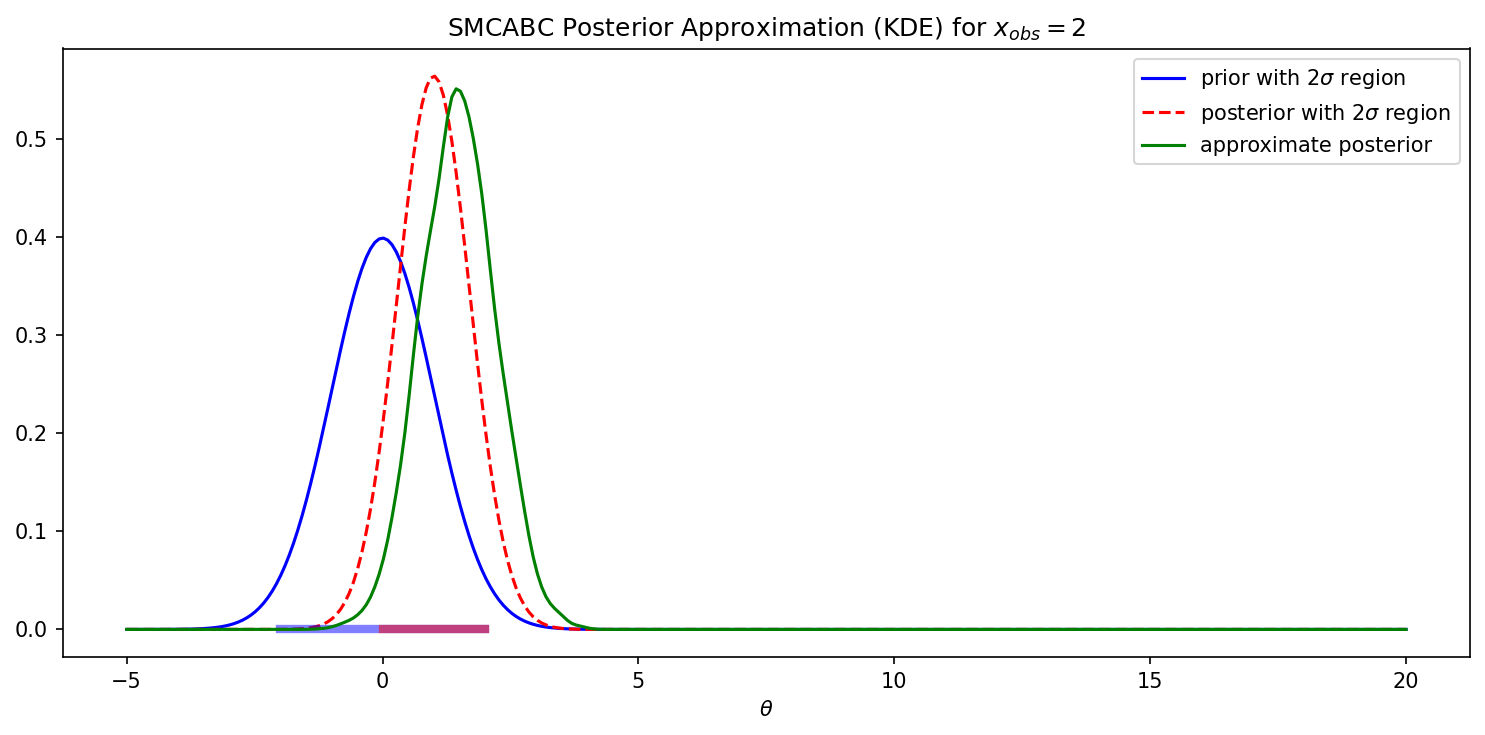

In [46]:
x_observed = 2 # Observed data
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(posterior.approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed, title=r"SMCABC Posterior Approximation (KDE) for $x_{obs} = $" + f"{x_observed}")

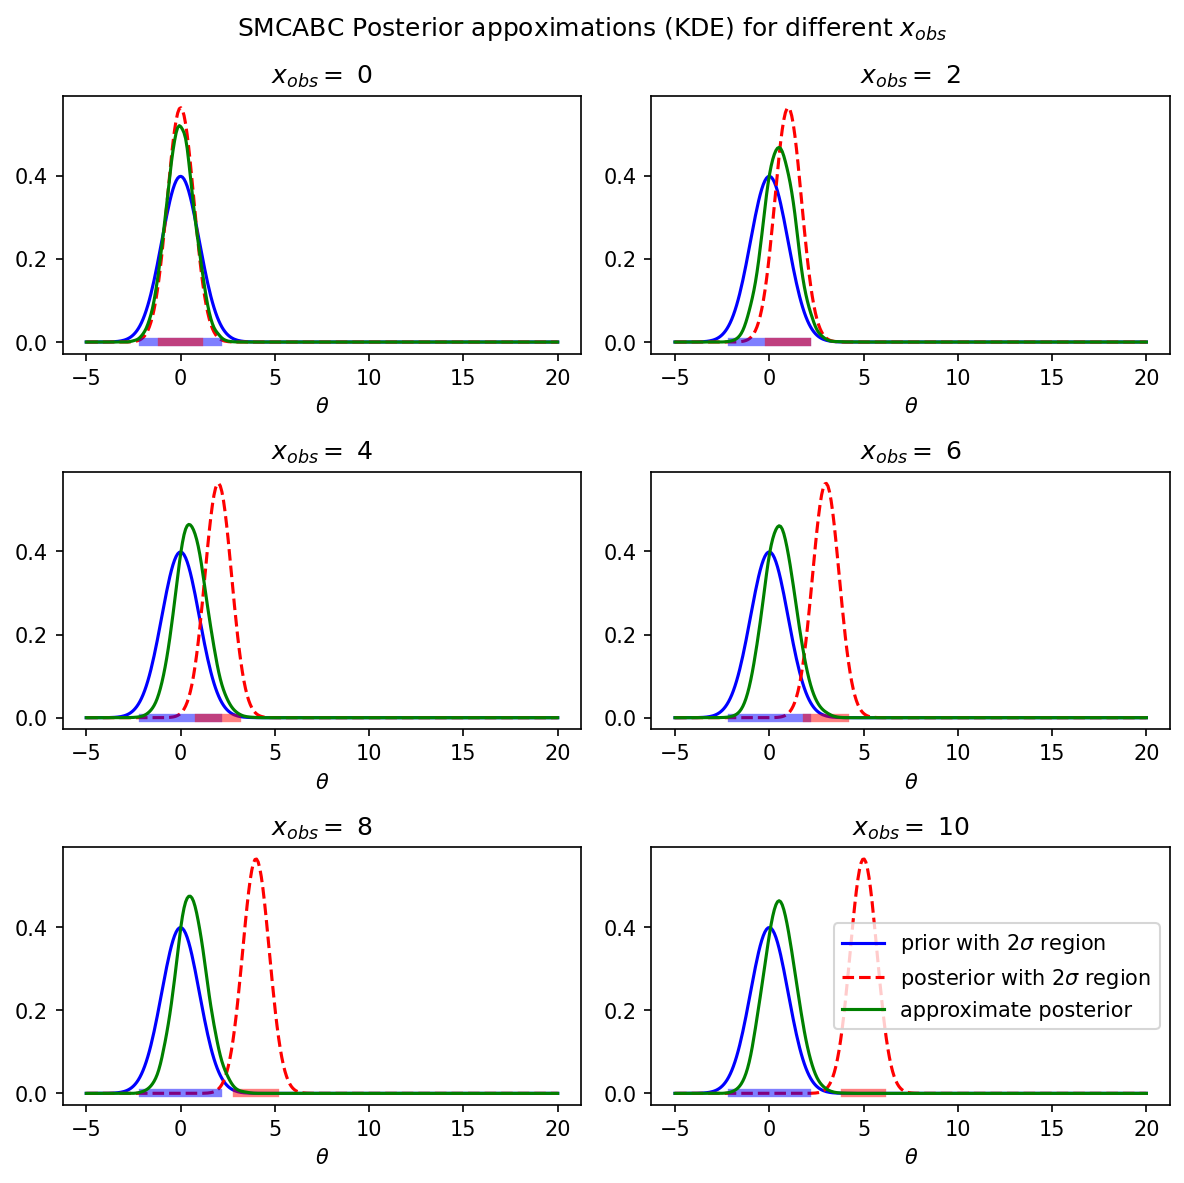

In [47]:
x_observed_values = [0, 2, 4, 6, 8, 10]
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(posterior.approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed_values, title=r"SMCABC Posterior appoximations (KDE) for different $x_{obs}$")

### SBC on SMCABC

In [7]:
from src.sbc.sbc_tools import sbc_ranks, plot_sbc_ecdf, plot_sbc_ecdf_diff, plot_sbc_histogram

In [10]:
N_iter = 100
N_samp = 1000
ranks = sbc_ranks(simulator, prior, posterior, N_iter=N_iter, N_samp=N_samp)

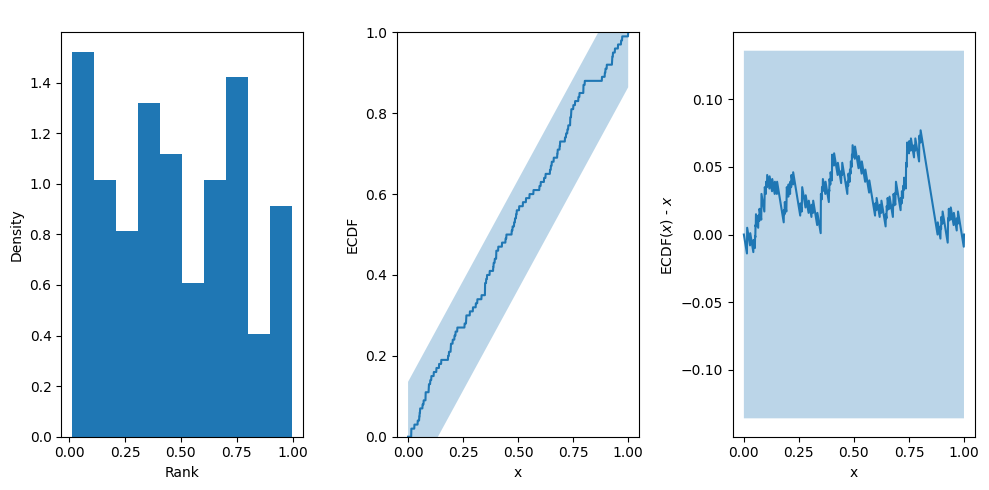

In [11]:
fig, ax = plt.subplots(figsize=(10,5), ncols=3)
plot_sbc_histogram(ranks, N_iter, N_samp, ax=ax[0], title=" ")
plot_sbc_ecdf(ranks, N_iter, N_samp, ax=ax[1], title=" ")
plot_sbc_ecdf_diff(ranks, N_iter, N_samp, ax=ax[2], title=" ")
plt.tight_layout()
plt.show()